This file uses the pre-trained TimeSeriesEncoder as a feature extractor to train the final XGBoost classifier for a 3-class (Buy/Sell/Hold) prediction.

Loads the ts_multitask_best.pth checkpoint and initialize the TimeSeriesEncoder and nn.Embedding layer. Meed to iterates through all processed_samples to generate features for the XGBoost model; additional features are also appended.

The final feature matrix is a stack of the following groups:


*   ts_encoding (128-dim): The vector produced by the encoder.
*   stock_embedding (16-dim): The per-stock representation learned in the encoder training process.
*   last_day_features (20-dim): The complete feature vector from the last day (T-1) of the local window (i.e., "today"'s OHLCVs, RSIs, MACDs, time_features, .etc).
*   stats_features (8-dim): Additional statistics (e.g., local_volatility, global_vol_mean, volatility_ratio) calculated from the global and local windows.

Labels are generated using the **Triple Barrier Method**:

**Sell (0)**: Price hits the **-3.0%** Stop-Loss barrier.

**Hold (1)**: The **5-day** Time Barrier is reached first.

**Buy (2)**: Price hits the **+4.0%** Profit-Take barrier.

Confusion matrix and a feature importance visualization of the final result can be found at the end of this file.

In [2]:
%pip install --upgrade xgboost
from google.colab import drive
drive.mount('/content/drive')
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from collections import OrderedDict
import random
import joblib
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 9.3 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.1.1
    Uninstalling xgboost-3.1.1:
      Successfully uninstalled xgboost-3.1.1
Mounted at /content/drive


In [3]:
BASE_DIR = '/content/drive/MyDrive/'
SAMPLES_DIR = os.path.join(BASE_DIR, 'processed_samples/')
PHASE_2_SAVE_PATH = os.path.join(BASE_DIR, 'ts_multitask_best.pth')
XGB_MODEL_SAVE_PATH = os.path.join(BASE_DIR, 'xgboost_classifier_v2.joblib')

LOCAL_WINDOW_SIZE = 30
GLOBAL_INPUT_DIM = 5
LOCAL_STOCK_INPUT_DIM = 20
LOCAL_MACRO_INPUT_DIM = 20
OHLCV_PLUS_INDICATORS_DIM = 14
TIME_FEAT_DIM = 6
STOCK_EMBED_DIM = 16
HIDDEN_DIM = 64
CNN_OUT_CHANNELS = 32
NUM_HEADS = 4
DROPOUT_RATE = 0.2

# Barriers for labelling
PROFIT_TAKE_THRESH = 0.04  # 4.0% profit target
STOP_LOSS_THRESH = -0.03 # -3.0% stop loss
TIME_BARRIER_DAYS = 5  # 5-day label window

LABEL_FEATURES = ['open', 'high', 'low', 'close', 'volume']
HIGH_IDX = LABEL_FEATURES.index('high') # 1
LOW_IDX = LABEL_FEATURES.index('low') # 2
CLOSE_IDX = LABEL_FEATURES.index('close') # 3


**Loading the pre-trained time-series encoder**

In [5]:
def init_hidden_state(context_vector, num_layers, num_directions):
    batch_size, hidden_dim = context_vector.shape
    h_0 = context_vector.unsqueeze(0).repeat(num_layers * num_directions, 1, 1)
    c_0 = context_vector.unsqueeze(0).repeat(num_layers * num_directions, 1, 1)
    return h_0, c_0

class GlobalContextEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
    def forward(self, long_term_series):
        _, h_n = self.gru(long_term_series)
        return h_n[-1]

class FiLMLayer(nn.Module):
    def __init__(self, conditional_dim, feature_dim):
        super().__init__()
        self.gamma_projection = nn.Linear(conditional_dim, feature_dim)
        self.beta_projection = nn.Linear(conditional_dim, feature_dim)
    def forward(self, series_data, conditional_vector):
        gamma = self.gamma_projection(conditional_vector).unsqueeze(1)
        beta = self.beta_projection(conditional_vector).unsqueeze(1)
        return gamma * series_data + beta

class LocalEncoder(nn.Module):
    def __init__(self, stock_feat_dim, ohlcv_feat_dim, time_feat_dim, macro_feat_dim,
                 stock_embed_dim, hidden_dim, cnn_out_channels, num_heads, dropout_rate):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.ohlcv_feat_dim = ohlcv_feat_dim
        self.film = FiLMLayer(stock_embed_dim, ohlcv_feat_dim)
        self.stock_cnn = nn.Conv1d(stock_feat_dim, cnn_out_channels, kernel_size=3, padding=1)
        self.stock_lstm = nn.LSTM(cnn_out_channels, hidden_dim, batch_first=True)
        self.macro_lstm = nn.LSTM(macro_feat_dim, hidden_dim, batch_first=True)
        self.attention = nn.MultiheadAttention(hidden_dim, num_heads, batch_first=True)
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout_rate)
    def forward(self, stock_series, macro_series, stock_embedding, global_context_vector):
        x_ohlcv = stock_series[:, :, :self.ohlcv_feat_dim]
        x_time = stock_series[:, :, self.ohlcv_feat_dim:]
        x_ohlcv_modulated = self.film(x_ohlcv, stock_embedding)
        x_stock_final = torch.cat([x_ohlcv_modulated, x_time], dim=2)
        cnn_out = F.relu(self.stock_cnn(x_stock_final.permute(0, 2, 1)).permute(0, 2, 1))
        h0_stock, c0_stock = init_hidden_state(global_context_vector, 1, 1)
        h_stock, _ = self.stock_lstm(cnn_out, (h0_stock, c0_stock))
        h_macro, _ = self.macro_lstm(macro_series)
        attn_output, _ = self.attention(h_stock, h_macro, h_macro)
        h_enhanced_stock = self.layer_norm(h_stock + attn_output)
        return h_stock[:, -1, :], h_enhanced_stock[:, -1, :]

class TimeSeriesEncoder(nn.Module):
    def __init__(self, **kwargs):
        super().__init__()
        self.global_encoder = GlobalContextEncoder(kwargs['global_input_dim'], kwargs['hidden_dim'])
        self.local_encoder = LocalEncoder(
            kwargs['local_stock_input_dim'], kwargs['ohlcv_plus_indicators_dim'], kwargs['time_feat_dim'],
            kwargs['local_macro_input_dim'],
            kwargs['stock_embed_dim'], kwargs['hidden_dim'],
            kwargs['cnn_out_channels'], kwargs['num_heads'], kwargs['dropout_rate']
        )
        self.output_dim = kwargs['hidden_dim'] * 2
    def forward(self, global_series, stock_series, macro_series, stock_embedding):
        global_context = self.global_encoder(global_series)
        h_stock_last, h_enhanced_last = self.local_encoder(stock_series, macro_series, stock_embedding, global_context)
        return torch.cat([h_stock_last, h_enhanced_last], dim=1)


In [6]:
def create_triple_barrier_labels(
    local_stock_tensor, label_tensor_batch, p0_local_batch,
    profit_take_pct, stop_loss_pct
):
    """
    Creates triple-barrier labels (0=Sell, 1=Hold, 2=Buy).
    Prices are denormalize.

    """
    B, T_local, F_local = local_stock_tensor.shape
    B, T_label, F_label = label_tensor_batch.shape
    device = label_tensor_batch.device

    p0_local_batch = p0_local_batch.view(B, 1).to(device)

    # 1. "Today's" (T-1) normalized close price
    norm_today_close = local_stock_tensor[:, -1, CLOSE_IDX]

    # Denormalizing
    p_today_close = (norm_today_close + 1.0) * p0_local_batch.squeeze()

    profit_barrier_price = p_today_close * (1.0 + profit_take_pct)
    stop_loss_barrier_price = p_today_close * (1.0 + stop_loss_pct)

    norm_high_prices = label_tensor_batch[:, :, HIGH_IDX]
    norm_low_prices = label_tensor_batch[:, :, LOW_IDX]

    p_future_high_path = (norm_high_prices + 1.0) * p0_local_batch
    p_future_low_path = (norm_low_prices + 1.0) * p0_local_batch

    profit_hit_days = (p_future_high_path >= profit_barrier_price.unsqueeze(1)).int()
    stop_loss_hit_days = (p_future_low_path <= stop_loss_barrier_price.unsqueeze(1)).int()

    profit_hit_on_day_N = profit_hit_days.argmax(dim=1)
    stop_loss_hit_on_day_N = stop_loss_hit_days.argmax(dim=1)

    profit_was_hit = (profit_hit_days.sum(dim=1) > 0)
    stop_loss_was_hit = (stop_loss_hit_days.sum(dim=1) > 0)

    # Initialize all labels to Hold (1)
    labels = torch.ones(B, dtype=torch.long, device=device)

    # Buy (2)
    buy_cond = profit_was_hit & (~stop_loss_was_hit | (profit_hit_on_day_N < stop_loss_hit_on_day_N))
    labels[buy_cond] = 2

    # Sell (0)
    sell_cond = stop_loss_was_hit & (~profit_was_hit | (stop_loss_hit_on_day_N <= profit_hit_on_day_N)) # Default
    labels[sell_cond] = 0

    return labels

In [7]:
class StockTimeSeriesDataset(Dataset):
    def __init__(self, file_paths, stock_to_idx):
        self.file_paths = file_paths
        self.stock_to_idx = stock_to_idx

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        try:
            data = torch.load(file_path, weights_only=False)
            stock_symbol = data['metadata']['stock_symbol']
            stock_idx = self.stock_to_idx.get(stock_symbol, -1)
            if stock_idx == -1:
                 return None

            return {
                'global_stock': data['global_stock'],
                'local_stock': data['local_stock'], # (30, 20)
                'local_macro': data['local_macro'], # (30, 20)
                'label_tensor': data['label'], # (5, 5)
                'stock_idx': torch.tensor(stock_idx, dtype=torch.long),
                'p0_local': torch.tensor(data['metadata']['p0_local'], dtype=torch.float32)
            }
        except Exception as e:
            return None


def generate_features_and_labels(file_list, dataset_class, stock_to_idx_map, encoder, embedding_layer, batch_size=64):

    dataset = dataset_class(file_list, stock_to_idx_map)

    def collate_fn_skip_none(batch):
        batch = [item for item in batch if item is not None]
        if not batch:
            return None
        return torch.utils.data.dataloader.default_collate(batch)

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_skip_none, num_workers=2, pin_memory=True)

    all_ts_features = []
    all_embeddings = []
    all_last_day_features = []
    all_global_stock = []
    all_local_stock = []
    all_labels = []

    encoder.eval()
    embedding_layer.eval()

    with torch.no_grad():
        for batch in tqdm(loader, desc="Generating features & labels"):
            if batch is None:
                continue

            global_stock = batch['global_stock'].to(device)
            local_stock = batch['local_stock'].to(device)
            local_macro = batch['local_macro'].to(device)
            stock_indices = batch['stock_idx'].to(device)
            label_tensor = batch['label_tensor'].to(device)
            p0_local_batch = batch['p0_local'].to(device)

            # Feature Generation
            embeddings = embedding_layer(stock_indices)
            last_day_features = local_stock[:, -1, :]
            ts_encoding = encoder(global_stock, local_stock, local_macro, embeddings)

            # Label Generation
            labels = create_triple_barrier_labels(
                local_stock, label_tensor, p0_local_batch,
                PROFIT_TAKE_THRESH, STOP_LOSS_THRESH
            )

            all_ts_features.append(ts_encoding.cpu().numpy())
            all_embeddings.append(embeddings.cpu().numpy())
            all_last_day_features.append(last_day_features.cpu().numpy())
            all_global_stock.append(global_stock.cpu().numpy())
            all_local_stock.append(local_stock.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    if not all_ts_features:
        empty_ts = np.array([]).reshape(0, encoder.output_dim)
        empty_emb = np.array([]).reshape(0, STOCK_EMBED_DIM)
        empty_last_day = np.array([]).reshape(0, LOCAL_STOCK_INPUT_DIM)
        empty_global = np.array([]).reshape(0, GLOBAL_WINDOW_SIZE, GLOBAL_INPUT_DIM)
        empty_local = np.array([]).reshape(0, LOCAL_WINDOW_SIZE, LOCAL_STOCK_INPUT_DIM)
        empty_labels = np.array([])
        return (empty_ts, empty_emb, empty_last_day, empty_global, empty_local), empty_labels

    X_ts = np.concatenate(all_ts_features, axis=0)
    X_emb = np.concatenate(all_embeddings, axis=0)
    X_last_day = np.concatenate(all_last_day_features, axis=0)
    X_global = np.concatenate(all_global_stock, axis=0)
    X_local = np.concatenate(all_local_stock, axis=0)
    y_labels = np.concatenate(all_labels, axis=0)

    return (X_ts, X_emb, X_last_day, X_global, X_local), y_labels

**Load Data & Generate Features**

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_val_dir = os.path.join(SAMPLES_DIR, 'train')
test_dir = os.path.join(SAMPLES_DIR, 'test')
all_train_val_files = [os.path.join(train_val_dir, f) for f in os.listdir(train_val_dir) if f.endswith('.pt')]
all_symbols = set()
for f in tqdm(all_train_val_files, desc="Scanning files for symbols"):
     try:
        meta = torch.load(f, weights_only=False)['metadata']
        all_symbols.add(meta['stock_symbol'])
     except Exception as e:
        print(f"Warning: Could not load metadata from {f}. Error: {e}")

stock_to_idx = {symbol: i for i, symbol in enumerate(sorted(list(all_symbols)))}
NUM_UNIQUE_STOCKS = len(stock_to_idx)
if NUM_UNIQUE_STOCKS == 0: raise ValueError("No unique stock symbols found.")
print(f"Found {NUM_UNIQUE_STOCKS} unique stocks.")

encoder_params = {
    'global_input_dim': GLOBAL_INPUT_DIM,
    'local_stock_input_dim': LOCAL_STOCK_INPUT_DIM,
    'local_macro_input_dim': LOCAL_MACRO_INPUT_DIM,
    'ohlcv_plus_indicators_dim': OHLCV_PLUS_INDICATORS_DIM,
    'time_feat_dim': TIME_FEAT_DIM,
    'stock_embed_dim': STOCK_EMBED_DIM,
    'hidden_dim': HIDDEN_DIM,
    'cnn_out_channels': CNN_OUT_CHANNELS,
    'num_heads': NUM_HEADS,
    'dropout_rate': DROPOUT_RATE
}
encoder = TimeSeriesEncoder(**encoder_params).to(device)
embedding_layer = nn.Embedding(NUM_UNIQUE_STOCKS, STOCK_EMBED_DIM).to(device)

checkpoint = torch.load(PHASE_2_SAVE_PATH, map_location=device)
embedding_layer.load_state_dict(checkpoint['embedding_layer_state_dict'])
encoder_weights = OrderedDict()
for k, v in checkpoint['model_state_dict'].items():
    if k.startswith('encoder.'):
        encoder_weights[k.replace('encoder.', '', 1)] = v
if not encoder_weights:
    raise ValueError("No 'encoder.' weights found in checkpoint. Check PHASE_2_SAVE_PATH.")
encoder.load_state_dict(encoder_weights, strict=True)
encoder.eval()
embedding_layer.eval()
print("Weights loaded successfully.")


print("\n Generating Training Features & Labels")
train_files = all_train_val_files
test_files = [os.path.join(test_dir, f) for f in os.listdir(test_dir) if f.endswith('.pt')]
test_files.sort(key=lambda x: os.path.basename(x).split('_')[1].replace('.pt', ''))

(X_train_ts, X_train_emb, X_train_last_day, X_train_global, X_train_local), y_train_labels = generate_features_and_labels(
    train_files, StockTimeSeriesDataset, stock_to_idx, encoder, embedding_layer, batch_size=64
)
print("\n Generating Test Features & Labels")
(X_test_ts, X_test_emb, X_test_last_day, X_test_global, X_test_local), y_test_labels = generate_features_and_labels(
    test_files, StockTimeSeriesDataset, stock_to_idx, encoder, embedding_layer, batch_size=64
)

print("\n Feature & Label Generation Complete ")
print(f"X_train_ts shape: {X_train_ts.shape} | X_train_emb shape: {X_train_emb.shape} | X_train_last_day shape: {X_train_last_day.shape}")
print(f"X_train_global shape: {X_train_global.shape} | X_train_local shape: {X_train_local.shape}")
print(f"y_train_labels shape: {y_train_labels.shape}")
print(f"X_test_ts shape:  {X_test_ts.shape} | X_test_emb shape: {X_test_emb.shape} | X_test_last_day shape: {X_test_last_day.shape}")
print(f"X_test_global shape: {X_test_global.shape} | X_test_local shape: {X_test_local.shape}")
print(f"y_test_labels shape:  {y_test_labels.shape}")

print(f"\nTrain label distribution (0=Sell, 1=Hold, 2=Buy): {np.bincount(y_train_labels)}")
print(f"Test label distribution (0=Sell, 1=Hold, 2=Buy): {np.bincount(y_test_labels)}")

Scanning files for symbols:   0%|          | 0/2232 [00:00<?, ?it/s]

Found 30 unique stocks.
Weights loaded successfully.

 Generating Training Features & Labels


Generating features & labels:   0%|          | 0/35 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



 Generating Test Features & Labels


Generating features & labels:   0%|          | 0/9 [00:00<?, ?it/s]


 Feature & Label Generation Complete 
X_train_ts shape: (2232, 128) | X_train_emb shape: (2232, 16) | X_train_last_day shape: (2232, 20)
X_train_global shape: (2232, 100, 5) | X_train_local shape: (2232, 30, 20)
y_train_labels shape: (2232,)
X_test_ts shape:  (558, 128) | X_test_emb shape: (558, 16) | X_test_last_day shape: (558, 20)
X_test_global shape: (558, 100, 5) | X_test_local shape: (558, 30, 20)
y_test_labels shape:  (558,)

Train label distribution (0=Sell, 1=Hold, 2=Buy): [919 588 725]
Test label distribution (0=Sell, 1=Hold, 2=Buy): [170 172 216]


Addional features: statistics aggregate


In [ ]:
# GLOBAL: ['open', 'high', 'low', 'close', 'volume']
G_CLOSE_IDX = 3
G_VOLUME_IDX = 4
# LOCAL: ['open', 'high', 'low', 'close', 'volume', 'sma_5', 'sma_20', 'ema_5', 'ema_20', 'macd', 'macd_signal', 'macd_hist', 'rsi_14', ...]
L_CLOSE_IDX = 3
L_MACD_IDX = 9
L_RSI_IDX = 12

# Names as in the plot
stats_features_names = [
    'global_volatility',
    'global_vol_mean',
    'local_volatility',
    'local_rsi_mean',
    'local_macd_mean',
    'local_price_slope',
    'volatility_ratio',
    'price_vs_global_mean'
]
NUM_NEW_STATS_FEATURES = len(stats_features_names)

FINAL_X_FEATURES = HIDDEN_DIM * 2 + STOCK_EMBED_DIM + LOCAL_STOCK_INPUT_DIM + NUM_NEW_STATS_FEATURES
print(f"New total feature count will be: {FINAL_X_FEATURES}")

def calculate_statistical_features(global_windows, local_windows, last_day_features):
    """Calculates statistical features from the raw window data."""

    last_day_norm_close = last_day_features[:, L_CLOSE_IDX]
    global_close = global_windows[:, :, G_CLOSE_IDX] # (N, 100)
    global_volume = global_windows[:, :, G_VOLUME_IDX] # (N, 100)
    local_close = local_windows[:, :, L_CLOSE_IDX] # (N, 30)
    local_rsi = local_windows[:, :, L_RSI_IDX] # (N, 30)
    local_macd = local_windows[:, :, L_MACD_IDX] # (N, 30)

    # Prevent division by zero
    epsilon = 1e-8

    global_vol = np.std(global_close, axis=1)
    global_vol_mean = np.mean(global_volume, axis=1)
    global_close_mean = np.mean(global_close, axis=1)
    local_vol = np.std(local_close, axis=1)
    local_rsi_mean = np.mean(local_rsi, axis=1)
    local_macd_mean = np.mean(local_macd, axis=1)

    x = np.arange(LOCAL_WINDOW_SIZE)
    local_price_slope = np.array([np.polyfit(x, row, 1)[0] for row in local_close])

    volatility_ratio = local_vol / (global_vol + epsilon)
    price_vs_global_mean = (last_day_norm_close - global_close_mean) / (global_vol + epsilon)

    stats_features = np.stack([
        global_vol,
        global_vol_mean,
        local_vol,
        local_rsi_mean,
        local_macd_mean,
        local_price_slope,
        volatility_ratio,
        price_vs_global_mean
    ], axis=1)

    return stats_features

X_train_stats = calculate_statistical_features(X_train_global, X_train_local, X_train_last_day)
X_test_stats = calculate_statistical_features(X_test_global, X_test_local, X_test_last_day)

print(f"X_train_stats shape: {X_train_stats.shape}")
print(f"X_test_stats shape: {X_test_stats.shape}")

del X_train_global, X_train_local, X_test_global, X_test_local

New total feature count will be: 172
X_train_stats shape: (2232, 8)
X_test_stats shape: (558, 8)


In [10]:
# Stacking the generated features
def combine_all_features(ts_features, stock_embeddings, last_day_features, stats_features):
    """
    Stacks all feature sets horizontally.
    """
    print(f"  Stacking: {ts_features.shape} + {stock_embeddings.shape} + {last_day_features.shape} + {stats_features.shape}")

    if ts_features.shape[0] == 0:
        print("  Warning: No features found to stack.")
        return np.array([]).reshape(0, FINAL_X_FEATURES)

    # stack all features horizontally
    engineered_features = np.hstack([ts_features, stock_embeddings, last_day_features, stats_features])

    print(f"  Final X matrix shape: {engineered_features.shape}")
    return engineered_features

X_train = combine_all_features(X_train_ts, X_train_emb, X_train_last_day, X_train_stats)
X_test = combine_all_features(X_test_ts, X_test_emb, X_test_last_day, X_test_stats)

del X_train_ts, X_train_emb, X_train_last_day, X_train_stats
del X_test_ts, X_test_emb, X_test_last_day, X_test_stats

if X_train.shape[0] == 0 or X_test.shape[0] == 0:
    raise ValueError("No data to train on after feature combination.")

  Stacking: (2232, 128) + (2232, 16) + (2232, 20) + (2232, 8)
  Final X matrix shape: (2232, 172)
  Stacking: (558, 128) + (558, 16) + (558, 20) + (558, 8)
  Final X matrix shape: (558, 172)


**Training the XGBoost**

In [ ]:
try:
    xgb_gpu_params = {'tree_method': 'hist', 'device': 'cuda'}
    _ = xgb.XGBClassifier(n_estimators=1, **xgb_gpu_params).fit(X_train[:2], y_train_labels[:2])
    print("XGBoost GPU support detected. Using 'hist' tree method with 'cuda' device.")
    xgb_params_extra = xgb_gpu_params
except Exception as e:
    print(f"XGBoost GPU support not available or failed ({e}). Using CPU.")
    xgb_params_extra = {'tree_method': 'hist'}

counts = np.bincount(y_train_labels)
if len(counts) < 3:
    print(f"Warning: Training data only contains {len(counts)} classes. Expected 3.")
    full_counts = np.zeros(3)
    full_counts[:len(counts)] = counts
    counts = full_counts
    if np.any(counts == 0):
        print("Warning: One or more classes have 0 samples in the training set.")

weights = np.where(counts > 0, len(y_train_labels) / (3 * counts), 0)
sample_weights = weights[y_train_labels]
print(f"Calculated class weights: {weights}")
print(f"Applying sample weights... (shape: {sample_weights.shape})")

xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    n_estimators=2500,
    learning_rate=0.001,
    max_depth=3,
    subsample=0.5,
    colsample_bytree=0.5,
    gamma=1,
    min_child_weight=3,
    reg_alpha=0.01,
    reg_lambda=0.01,
    random_state=233,
    use_label_encoder=False,
    **xgb_params_extra
)

eval_set = [(X_train, y_train_labels), (X_test, y_test_labels)]

print("Starting XGBoost training...")
xgb_model.fit(
    X_train, y_train_labels,
    sample_weight=sample_weights,
    eval_set=eval_set,
    #early_stopping_rounds=200,
    verbose=100
)
print("XGBoost training finished.")

joblib.dump(xgb_model, XGB_MODEL_SAVE_PATH)
print(f"XGBoost model saved to {XGB_MODEL_SAVE_PATH}")

XGBoost GPU support not available or failed (Invalid classes inferred from unique values of `y`.  Expected: [0 1], got [1 2]). Using CPU.
Calculated class weights: [0.80957563 1.26530612 1.0262069 ]
Applying sample weights... (shape: (2232,))
Starting XGBoost training...
[0]	validation_0-mlogloss:1.09847	validation_1-mlogloss:1.09858


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [08:09:35] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[100]	validation_0-mlogloss:1.08336	validation_1-mlogloss:1.09272
[200]	validation_0-mlogloss:1.06962	validation_1-mlogloss:1.08793
[300]	validation_0-mlogloss:1.05673	validation_1-mlogloss:1.08356
[400]	validation_0-mlogloss:1.04468	validation_1-mlogloss:1.07976
[500]	validation_0-mlogloss:1.03352	validation_1-mlogloss:1.07650
[600]	validation_0-mlogloss:1.02285	validation_1-mlogloss:1.07371
[700]	validation_0-mlogloss:1.01264	validation_1-mlogloss:1.07115
[800]	validation_0-mlogloss:1.00312	validation_1-mlogloss:1.06915
[900]	validation_0-mlogloss:0.99398	validation_1-mlogloss:1.06743
[1000]	validation_0-mlogloss:0.98519	validation_1-mlogloss:1.06559
[1100]	validation_0-mlogloss:0.97696	validation_1-mlogloss:1.06390
[1200]	validation_0-mlogloss:0.96897	validation_1-mlogloss:1.06284
[1300]	validation_0-mlogloss:0.96142	validation_1-mlogloss:1.06180
[1400]	validation_0-mlogloss:0.95419	validation_1-mlogloss:1.06106
[1500]	validation_0-mlogloss:0.94722	validation_1-mlogloss:1.06028
[160

Evaluation & Visualization

Loaded saved model for evaluation.

Test Set Accuracy: 0.4319

Classification Report:
              precision    recall  f1-score   support

    Sell (0)       0.36      0.34      0.35       170
    Hold (1)       0.44      0.51      0.47       172
     Buy (2)       0.48      0.44      0.46       216

    accuracy                           0.43       558
   macro avg       0.43      0.43      0.43       558
weighted avg       0.43      0.43      0.43       558


Confusion Matrix:
[[57 57 56]
 [36 88 48]
 [66 54 96]]


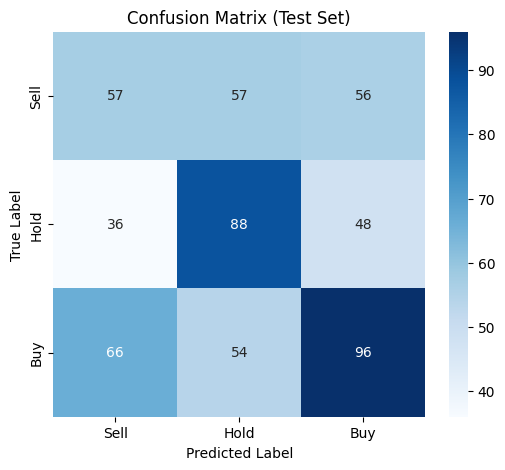


Sample Predicted Probabilities (Sell, Hold, Buy):
[[0.51648957 0.15438698 0.32912347]
 [0.323094   0.44679832 0.23010772]
 [0.4573795  0.23646267 0.30615783]
 [0.31070903 0.42972806 0.25956297]
 [0.38935217 0.35492423 0.25572363]
 [0.36066285 0.21908097 0.4202561 ]
 [0.29955578 0.37926987 0.32117432]
 [0.38320678 0.27052566 0.34626752]
 [0.3044361  0.44737276 0.2481912 ]
 [0.32245693 0.30086103 0.37668204]]

--- Evaluation Complete ---
You can now add more visualization cells below.


In [11]:
try:
    xgb_model_loaded = joblib.load(XGB_MODEL_SAVE_PATH)
    print("Loaded saved model for evaluation.")
except Exception as e:
    print(f"Could not load saved model, using model from memory. Error: {e}")
    xgb_model_loaded = xgb_model

y_pred_proba = xgb_model_loaded.predict_proba(X_test)
y_pred_labels = np.argmax(y_pred_proba, axis=1)

accuracy = accuracy_score(y_test_labels, y_pred_labels)
print(f"\nTest Set Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_labels, y_pred_labels, target_names=['Sell (0)', 'Hold (1)', 'Buy (2)'], zero_division=0))


# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test_labels, y_pred_labels)
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Sell', 'Hold', 'Buy'], yticklabels=['Sell', 'Hold', 'Buy'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Test Set)')
plt.show()


print("\nSample Predicted Probabilities (Sell, Hold, Buy):")
print(y_pred_proba[:10])

print("\n--- Evaluation Complete ---")
print("You can now add more visualization cells below.")


--- 12. Analyzing Feature Importance ---
Loaded saved model from /content/drive/MyDrive/xgboost_classifier_v2.joblib for analysis.

Top 30 Most Important Features:
                  feature  importance
164     global_volatility    0.020026
166      local_volatility    0.015929
134                 emb_6    0.009895
161            ld_dom_sin    0.009396
128                 emb_0    0.008764
162            ld_moy_cos    0.008692
81              ts_enc_81    0.008098
146                ld_low    0.008080
158            ld_dow_cos    0.007883
141                emb_13    0.007850
133                 emb_5    0.007706
151              ld_ema_5    0.007661
147              ld_close    0.007660
160            ld_dom_cos    0.007538
91              ts_enc_91    0.007521
171  price_vs_global_mean    0.007391
130                 emb_2    0.007310
85              ts_enc_85    0.007252
170      volatility_ratio    0.007112
45              ts_enc_45    0.007086
159            ld_dow_sin    0.007028

/tmp/ipython-input-574954154.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=top_features_df, palette='viridis')


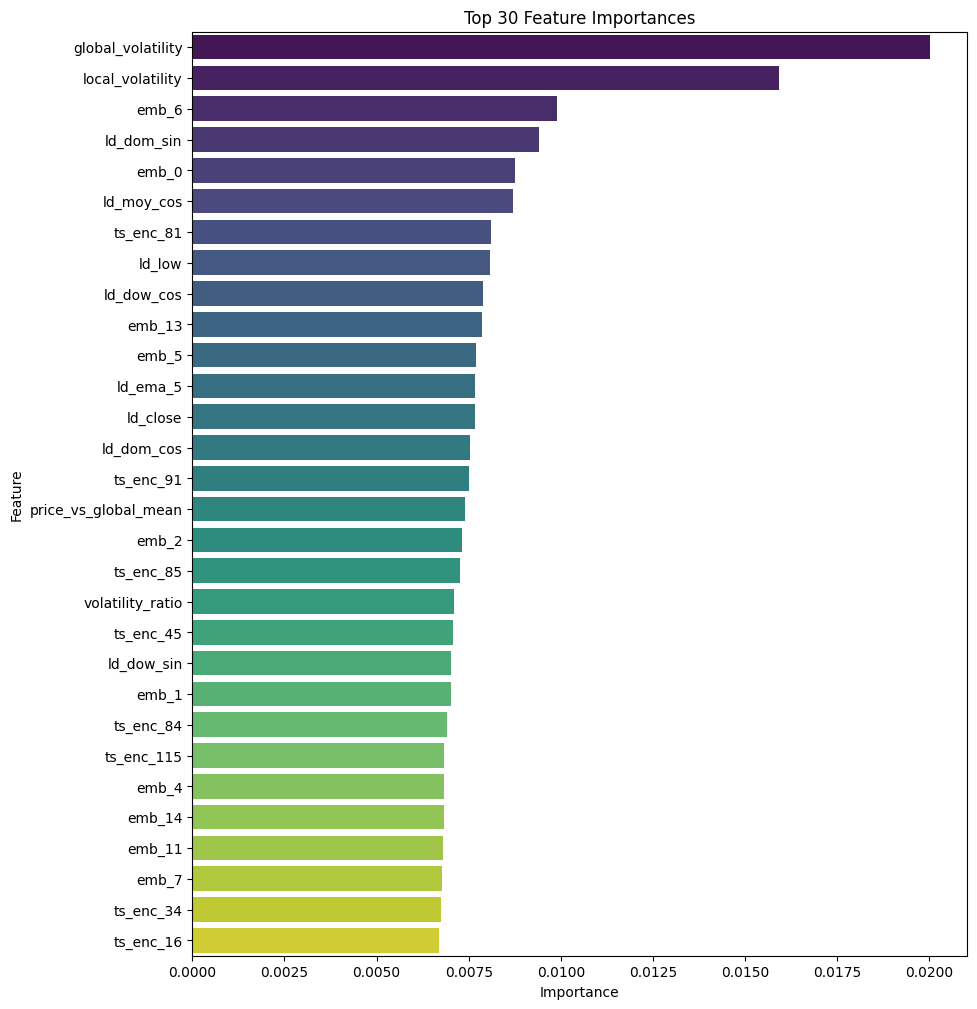

In [ ]:
import pandas as pd

# TS Encoding (128 features)
ts_features_names = [f'ts_enc_{i}' for i in range(HIDDEN_DIM * 2)]

# Stock Embedding (16 features)
emb_features_names = [f'emb_{i}' for i in range(STOCK_EMBED_DIM)]

# Last Day Features (20 features)
last_day_features_names = [
    'ld_open', 'ld_high', 'ld_low', 'ld_close', 'ld_volume',
    'ld_sma_5', 'ld_sma_20', 'ld_ema_5', 'ld_ema_20',
    'ld_macd', 'ld_macd_signal', 'ld_macd_hist',
    'ld_rsi_14', 'ld_atr_14',
    'ld_dow_cos', 'ld_dow_sin',
    'ld_dom_cos', 'ld_dom_sin',
    'ld_moy_cos', 'ld_moy_sin'
]

# Statistical Features (8 features)
stats_features_names = [
    'global_volatility',
    'global_vol_mean',
    'local_volatility',
    'local_rsi_mean',
    'local_macd_mean',
    'local_price_slope',
    'volatility_ratio',
    'price_vs_global_mean'
]

all_feature_names = ts_features_names + emb_features_names + last_day_features_names + stats_features_names

if len(all_feature_names) != xgb_model_loaded.n_features_in_:
    print(f"ERROR: Feature name count ({len(all_feature_names)}) does not match model feature count ({xgb_model_loaded.n_features_in_})")
else:
    importance_df = pd.DataFrame({
        'feature': all_feature_names,
        'importance': xgb_model_loaded.feature_importances_
    })

    top_features_df = importance_df.sort_values(by='importance', ascending=False).head(30)

    print("\nTop 30 Most Important Features:")
    print(top_features_df)

    plt.figure(figsize=(10, 12))
    sns.barplot(x='importance', y='feature', data=top_features_df, palette='viridis')
    plt.title('Top 30 Feature Importances')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()

Plotting sample for: INTC (Date: 2025-08-21)


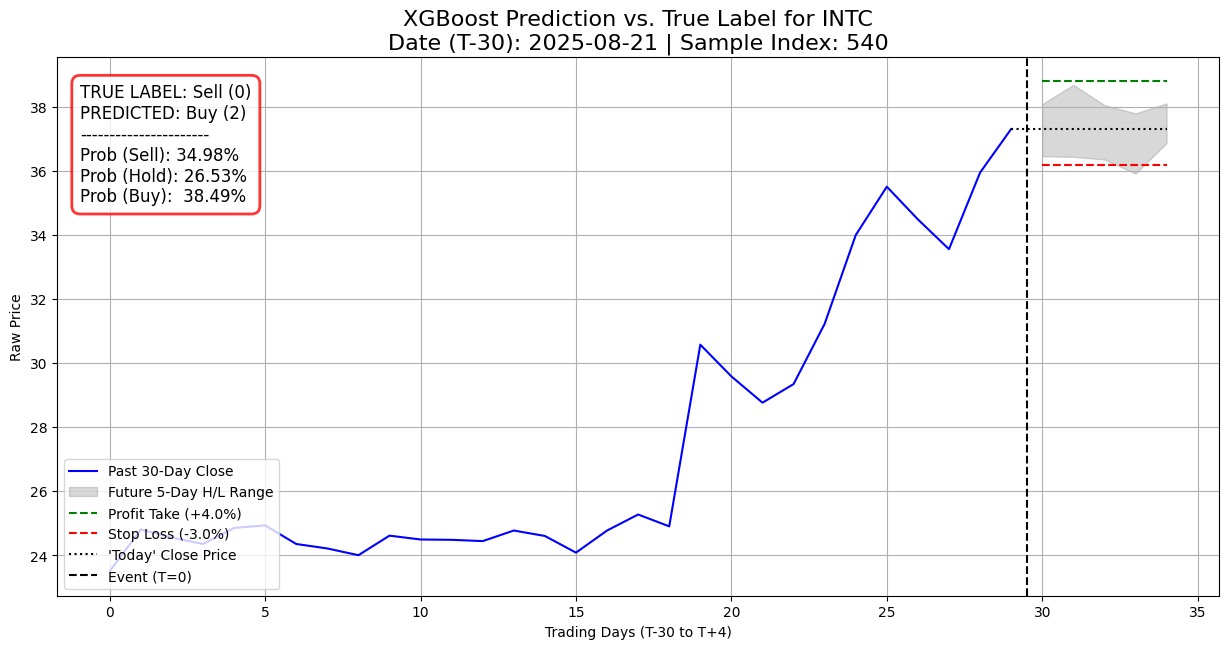

In [46]:
SAMPLE_INDEX_TO_PLOT = 540#######

if SAMPLE_INDEX_TO_PLOT >= len(test_files):
    print(f"Error: SAMPLE_INDEX_TO_PLOT ({SAMPLE_INDEX_TO_PLOT}) is out of bounds for test set (size {len(test_files)}).")
    print("Defaulting to sample 0.")
    SAMPLE_INDEX_TO_PLOT = 0

file_path = test_files[SAMPLE_INDEX_TO_PLOT]
true_label = y_test_labels[SAMPLE_INDEX_TO_PLOT]
predicted_label = y_pred_labels[SAMPLE_INDEX_TO_PLOT]
predicted_proba = y_pred_proba[SAMPLE_INDEX_TO_PLOT]

try:
    sample_data = torch.load(file_path, weights_only=False)
    metadata = sample_data['metadata']
    p0_local = metadata['p0_local']
    stock_symbol = metadata['stock_symbol']
    date = metadata['local_start_date']

    local_tensor = sample_data['local_stock'] # (30, 20)
    label_tensor = sample_data['label'] # (5, 5)

    print(f"Plotting sample for: {stock_symbol} (Date: {date})")

    # 1. Past 30 Days (Local Window)
    local_close_norm = local_tensor[:, CLOSE_IDX].numpy()
    local_close_raw = (local_close_norm + 1.0) * p0_local

    # 2. Future 5 Days (Label Window)
    label_high_norm = label_tensor[:, HIGH_IDX].numpy()
    label_high_raw = (label_high_norm + 1.0) * p0_local

    label_low_norm = label_tensor[:, LOW_IDX].numpy()
    label_low_raw = (label_low_norm + 1.0) * p0_local

    # The reference price is the last day of local window
    today_close_raw = local_close_raw[-1]

    profit_barrier = today_close_raw * (1.0 + PROFIT_TAKE_THRESH)
    stop_loss_barrier = today_close_raw * (1.0 + STOP_LOSS_THRESH)

    x_past = np.arange(0, LOCAL_WINDOW_SIZE) # 0 to 29
    x_future = np.arange(LOCAL_WINDOW_SIZE, LOCAL_WINDOW_SIZE + TIME_BARRIER_DAYS) # 30 to 34

    plt.figure(figsize=(15, 7))
    plt.plot(x_past, local_close_raw, label='Past 30-Day Close', color='blue')
    plt.fill_between(
        x_future,
        label_low_raw,
        label_high_raw,
        color='gray',
        alpha=0.3,
        label='Future 5-Day H/L Range'
    )

    plt.plot(
        x_future,
        [profit_barrier] * TIME_BARRIER_DAYS,
        label=f'Profit Take ({PROFIT_TAKE_THRESH*100:+.1f}%)',
        color='green',
        linestyle='--'
    )
    plt.plot(
        x_future,
        [stop_loss_barrier] * TIME_BARRIER_DAYS,
        label=f'Stop Loss ({STOP_LOSS_THRESH*100:+.1f}%)',
        color='red',
        linestyle='--'
    )
    plt.plot(
        [x_past[-1], x_future[-1]], # from T-1 to T+4
        [today_close_raw] * 2,
        label='\'Today\' Close Price',
        color='black',
        linestyle=':'
    )

    plt.axvline(x=LOCAL_WINDOW_SIZE - 0.5, color='black', linestyle='--', label='Event (T=0)')

    label_map = {0: 'Sell (0)', 1: 'Hold (1)', 2: 'Buy (2)'}

    title = (
        f"XGBoost Prediction vs. True Label for {stock_symbol}\n"
        f"Date (T-30): {date} | Sample Index: {SAMPLE_INDEX_TO_PLOT}"
    )
    plt.title(title, fontsize=16)

    text_content = (
        f"TRUE LABEL: {label_map.get(true_label, 'Unknown')}\n"
        f"PREDICTED: {label_map.get(predicted_label, 'Unknown')}\n"
        f"----------------------\n"
        f"Prob (Sell): {predicted_proba[0]:.2%}\n"
        f"Prob (Hold): {predicted_proba[1]:.2%}\n"
        f"Prob (Buy):  {predicted_proba[2]:.2%}"
    )

    # Determine color for the result text
    result_color = 'green' if true_label == predicted_label else 'red'

    plt.text(
        0.02, 0.95,
        text_content,
        transform=plt.gca().transAxes,
        fontsize=12,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor=result_color, linewidth=2)
    )

    plt.legend(loc='lower left')
    plt.ylabel("Raw Price")
    plt.xlabel("Trading Days (T-30 to T+4)")
    plt.grid(True)
    plt.show()

except Exception as e:
    print(f"Error plotting sample {SAMPLE_INDEX_TO_PLOT}: {e}")